Example 5.6 - Choke Valve (pg. 201)

<function matplotlib.pyplot.show(close=None, block=None)>

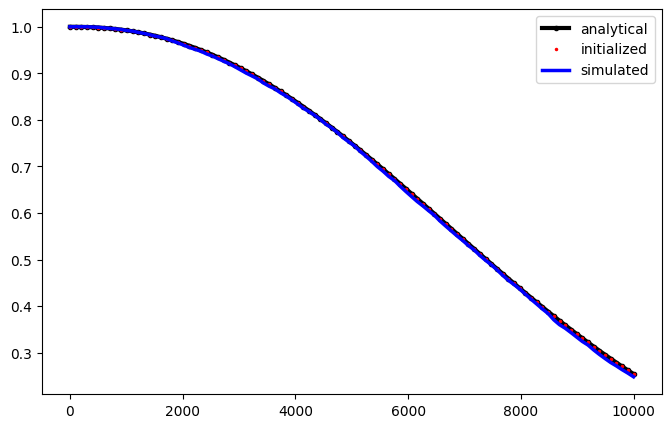

In [32]:
import numpy as np
import sympy as sp
import math 
import matplotlib.pyplot as plt

from component_objects.component_weibull import WeibullComponent

# given parameters
shape = 2.25    # increasing failure rate
scale = 8695

# exercise answers
t = np.linspace(0, 10000, 100)
R_t_analytical = np.exp(-(t/scale)**shape)      # function of t
# t = sp.Symbol("t", real=True, positive=True)
# R_t_analytical = sp.exp((-t/scale)**shape)      # function of t
MTTF = scale* math.gamma(1+1/shape)             # hr 

# object simulation
num_simulated = 10000
TTFs = np.zeros(num_simulated)
for i in range(num_simulated):
    # initalizing a component with given parameters
    choke_valve = WeibullComponent("choke valve", MTTF, MTTR=0, shape=shape)
    TTFs[i] = choke_valve.time_to_failure
R_t_simulated = np.array([np.mean(TTFs > time_point) for time_point in t])

# plot the analytic, initialized and simulated R(t)
plt.figure(figsize=(8,5))
plt.plot(t, R_t_analytical, '.-k',label= "analytical", linewidth=3)
plt.plot(t, choke_valve.R_t(t), '.r', label= "initialized", markersize=3)
plt.plot(t, R_t_simulated, '-b', label = "simulated", linewidth = 2.5)
plt.legend()
plt.show
